In [9]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, cross_validate, learning_curve, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, matthews_corrcoef,
    cohen_kappa_score, log_loss, brier_score_loss, confusion_matrix,
    classification_report, roc_curve, auc, precision_recall_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
})
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
pd.set_option("display.max_columns", None)

PALETTE = {"Not creditworthy": "#C44E52", "Creditworthy": "#55A868"}
LABEL_MAP = {0: "Not creditworthy", 1: "Creditworthy"}


In [4]:
credit = pd.read_csv("data.csv", header=0)
credit.head()

,Age,Gender,Education,Income,Debt,Credit_Score,Loan_Amount,Loan_Term,Num_Credit_Cards,Payment_History,Employment_Status,Residence_Type,Marital_Status,Creditworthiness
0,56,Female,Master,149406,34089,581,49200,60,4,Bad,Unemployed,Rented,Single,1
1,69,Female,High School,78896,8626,648,20147,24,7,Good,Employed,Mortgaged,Married,1
2,46,Female,Master,119339,46281,329,41307,12,8,Bad,Unemployed,Owned,Single,1
3,32,Male,High School,131067,29403,816,19019,60,8,Bad,Employed,Owned,Single,1
4,60,Male,PhD,38001,30032,673,16317,36,4,Average,Employed,Rented,Married,0


In [7]:
numerical_features = credit.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = credit.select_dtypes(include=["object", "category"]).columns.tolist()

%matplotlib inline

/tmp/ipykernel_2166/3271636891.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = credit.select_dtypes(include=["object", "category"]).columns.tolist()


/tmp/ipykernel_2166/2978752782.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_eda, x=feat, hue="Creditworthiness_label", fill=True,


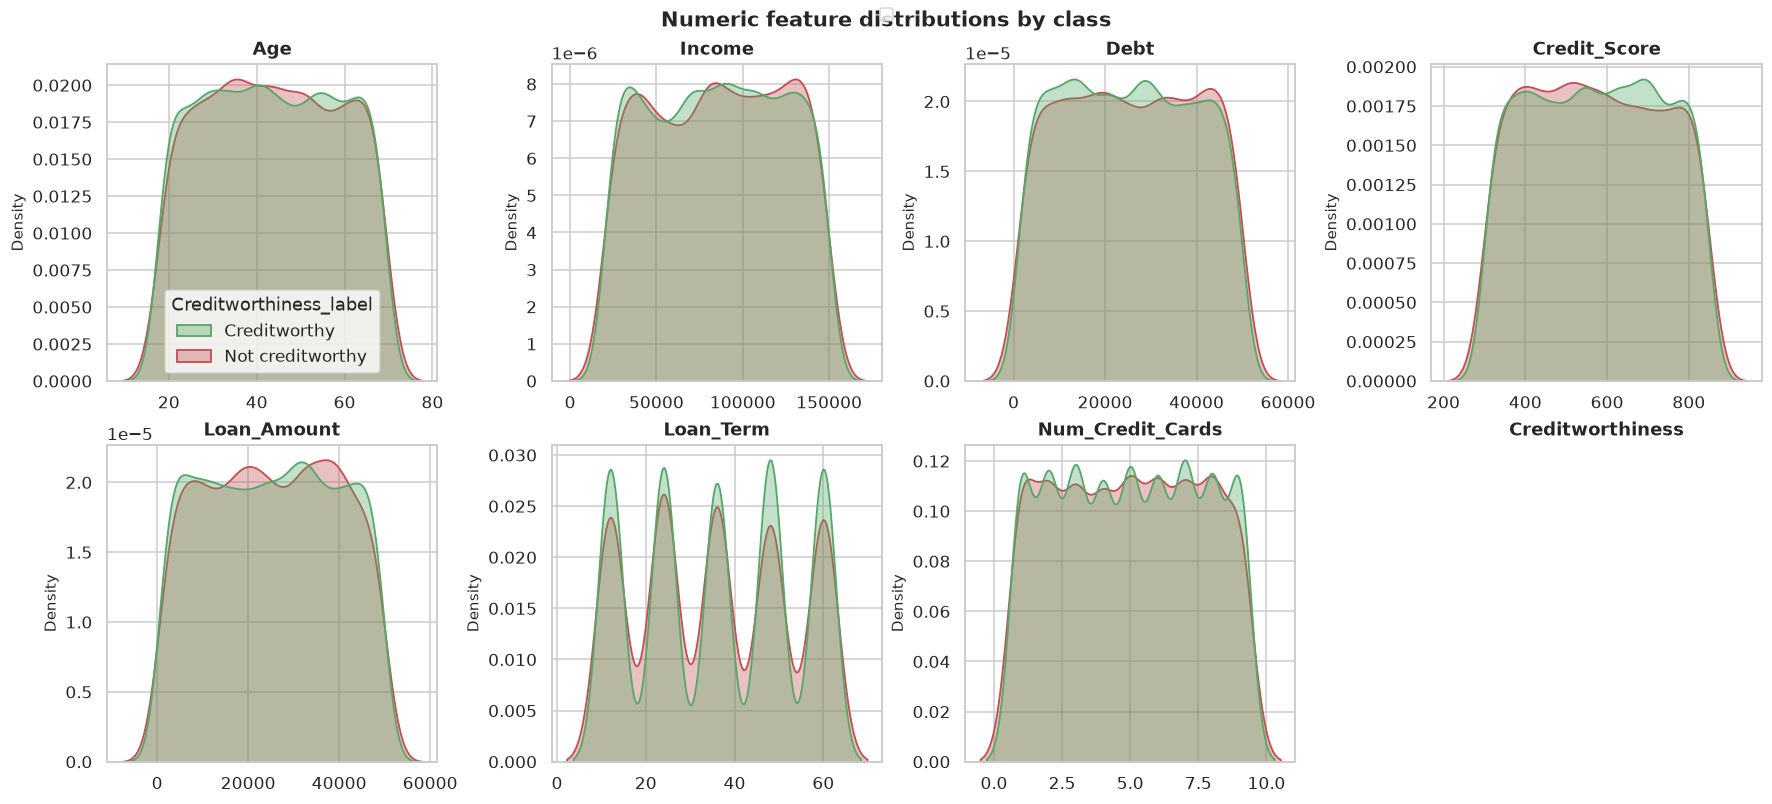

In [10]:
df_eda = credit.copy()
df_eda["Creditworthiness_label"] = df_eda["Creditworthiness"].map(LABEL_MAP)

fig, axes = plt.subplots(2, 4, figsize=(16, 7.2), constrained_layout=True)
for i, (ax, feat) in enumerate(zip(axes.flat, numerical_features)):
    sns.kdeplot(data=df_eda, x=feat, hue="Creditworthiness_label", fill=True,
                common_norm=False, palette=PALETTE, alpha=0.35, linewidth=1.2, ax=ax)
    ax.set_title(feat)
    ax.set_xlabel("")
    if i > 0 and ax.get_legend() is not None:
        ax.get_legend().remove()
axes.flat[-1].axis("off")
h, l = axes.flat[0].get_legend_handles_labels()
fig.legend(h, l, loc="outside upper center", ncol=2, frameon=True)
fig.suptitle("Numeric feature distributions by class", fontsize=14, fontweight="bold")
plt.show()

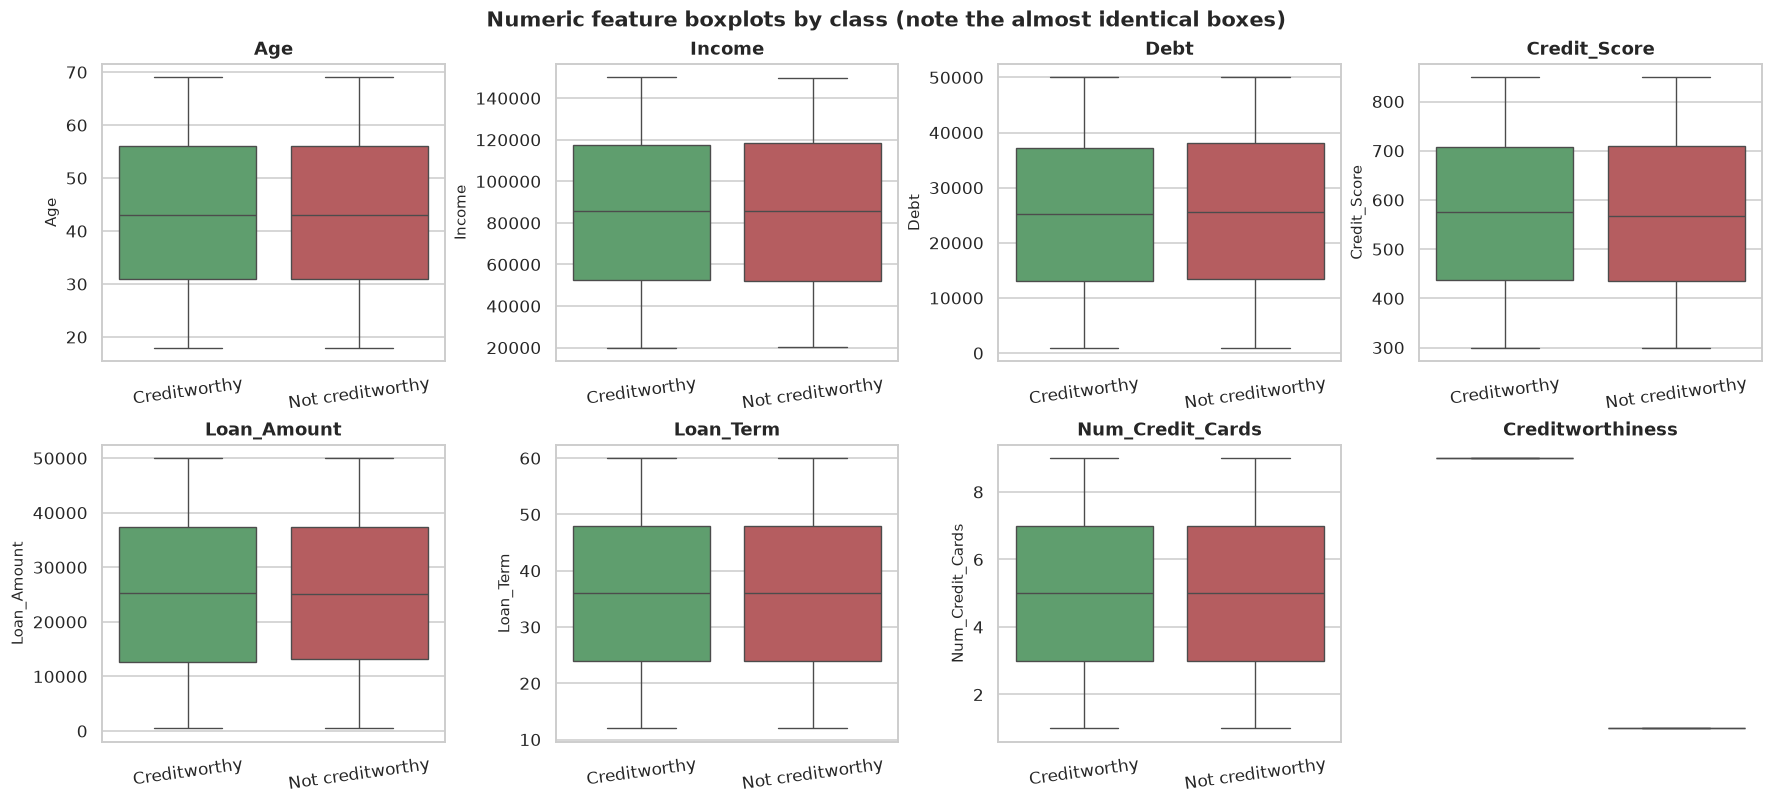

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7.2), constrained_layout=True)
for i, (ax, feat) in enumerate(zip(axes.flat, numerical_features)):
    sns.boxplot(data=df_eda, x="Creditworthiness_label", y=feat,
                hue="Creditworthiness_label", palette=PALETTE, legend=False,
                fliersize=1.2, linewidth=0.9, ax=ax)
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=8)
axes.flat[-1].axis("off")
fig.suptitle("Numeric feature boxplots by class (note the almost identical boxes)",
             fontsize=14, fontweight="bold")
plt.show()

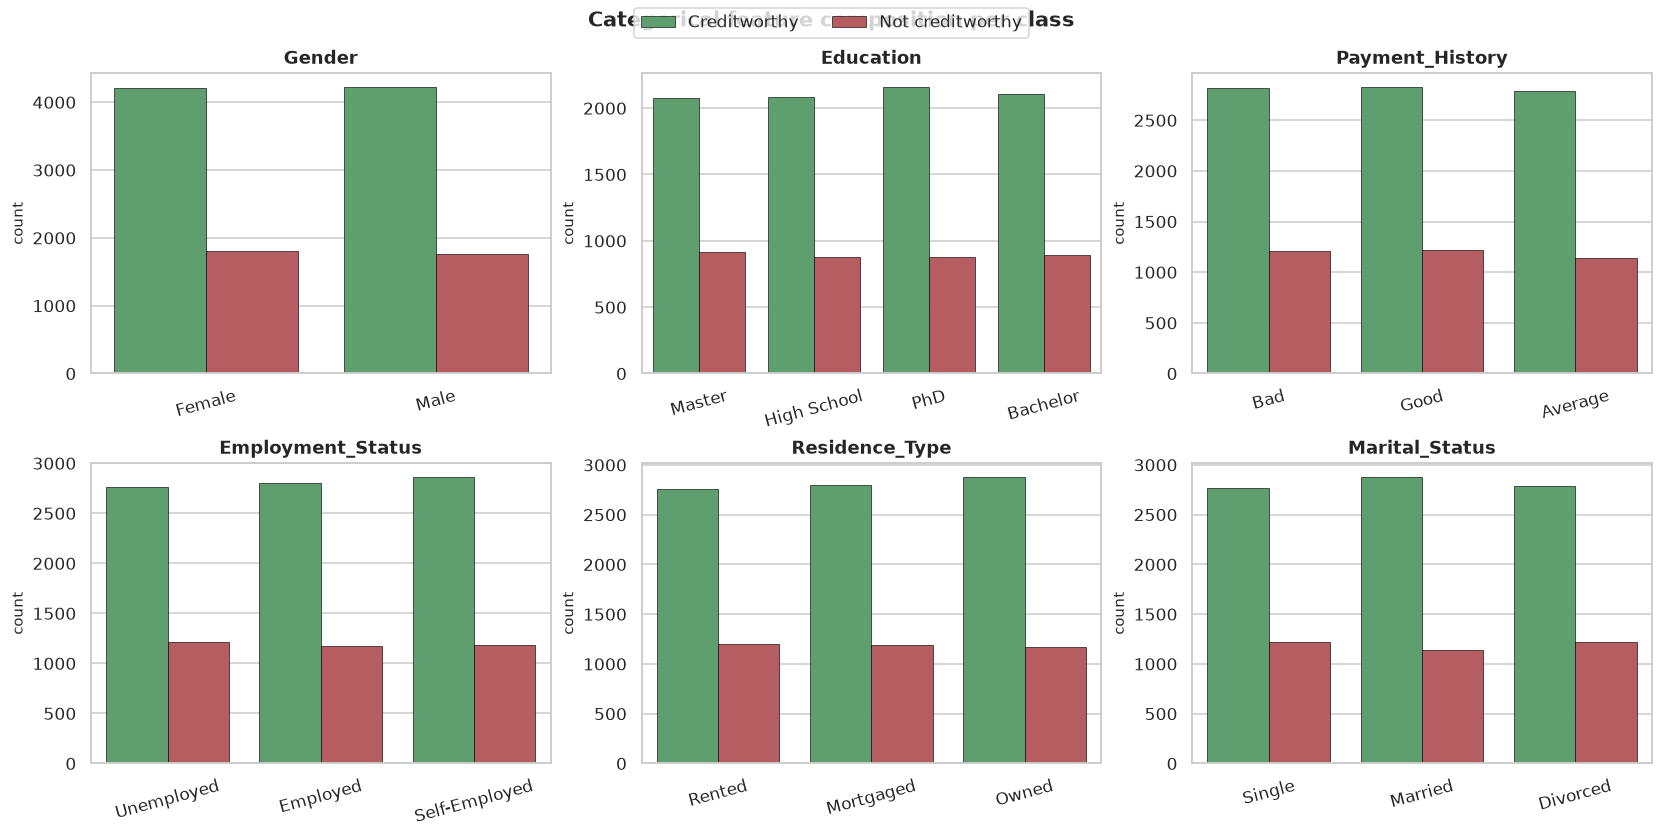

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), constrained_layout=True)
for ax, feat in zip(axes.flat, categorical_features):
    sns.countplot(data=df_eda, x=feat, hue="Creditworthiness_label",
                  palette=PALETTE, edgecolor="black", linewidth=0.4, ax=ax)
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
    if ax.get_legend() is not None:
        ax.get_legend().remove()
h, l = axes.flat[0].get_legend_handles_labels()
fig.legend(h, l, loc="outside upper center", ncol=2, frameon=True)
fig.suptitle("Categorical feature composition per class", fontsize=14, fontweight="bold")
plt.show()

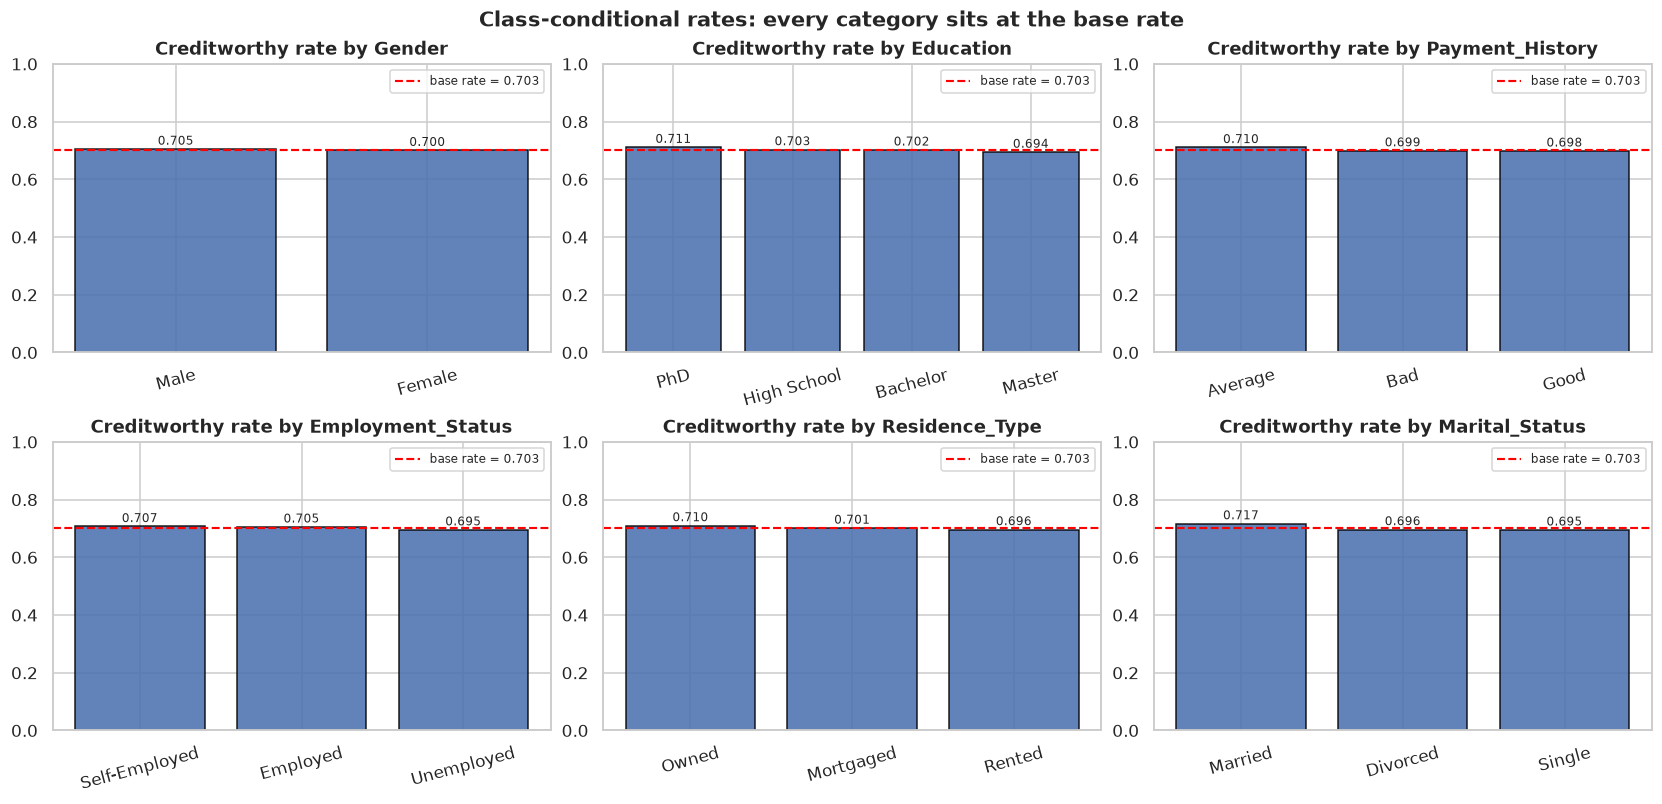

In [33]:
base_rate = credit["Creditworthiness"].mean()
fig, axes = plt.subplots(2, 3, figsize=(15, 7.2), constrained_layout=True)
for ax, feat in zip(axes.flat, categorical_features):
    rate = credit.groupby(feat)["Creditworthiness"].mean().sort_values(ascending=False)
    ax.bar(rate.index, rate.values, color="#4C72B0", alpha=0.88, edgecolor="black")
    ax.axhline(base_rate, color="red", ls="--", lw=1.4,
               label=f"base rate = {base_rate:.3f}")
    for x, v in enumerate(rate.values):
        ax.text(x, v + 0.015, f"{v:.3f}", ha="center", fontsize=8)
    ax.set_ylim(0, 1.0)
    ax.set_title(f"Creditworthy rate by {feat}")
    ax.tick_params(axis="x", rotation=15)
    ax.legend(fontsize=8, loc="upper right")
fig.suptitle("Class-conditional rates: every category sits at the base rate",
             fontsize=14, fontweight="bold")
plt.show()

In [36]:
corr = credit[numerical_features + ["Creditworthiness"]].corr()
target_corr = corr["Creditworthiness"].drop("Creditworthiness").sort_values(ascending = False)
    rates = df.groupby(feat)["Creditworthiness"].mean()
    print(f"  {feat:20s} spread = {rates.max() - rates.min():.4f}")

X = credit.drop(columns="Creditworthiness").copy()
y = credit["Creditworthiness"].copy()


IndentationError: unexpected indent (2747420898.py, line 3)